In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
from matplotlib import pyplot as plt
plt.rcParams['font.family']='Times New Roman,Microsoft YaHei'# 设置字体族，中文为微软雅黑，英文为Times New Roman
plt.rcParams['mathtext.fontset'] = 'stix' # 设置数%matplotlib qt学公式字体为stix
plt.style.use('seaborn-v0_8-paper')
# 设置全局参数
plt.rcParams['figure.facecolor'] = 'white'  # 设置图形的背景为透明
plt.rcParams['axes.facecolor'] = 'white'    # 设置轴域的背景为透明
plt.rcParams['savefig.facecolor'] = 'white' # 保存图像时背景透明
import matplotlib
# matplotlib.use('TkAgg')
%matplotlib inline

In [2]:
import openchord as ocd
import networkx as nx
import networkx.algorithms
from matplotlib.colors import LinearSegmentedColormap
from networkx.drawing.nx_agraph import to_agraph
import os
import pickle
from tqdm import tqdm
import gravis as gv

In [3]:
from sklearn.preprocessing import MinMaxScaler
import matplotlib.colors as mcolors
from palettable.scientific.sequential import Nuuk_13
from palettable.scientific.sequential import Davos_4
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patheffects as path_effects
from legendkit import size_legend, colorart
from legendkit import cat_legend, vstack, hstack
from palettable.tableau import GreenOrange_6

def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=100):
    new_colors = cmap(np.linspace(minval, maxval, n))
    new_cmap = LinearSegmentedColormap.from_list('trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval), new_colors)
    return new_cmap
def reverse_colormap(cmap, name='reversed_cmap'):
    reverse = []
    k = []  
    for key, channel in cmap._segmentdata.items():
        data = []
        for t, c1, c2 in channel:
            data.append((1-t, c1, c2))
        reverse.append((key, data[::-1]))
        k.append(key) 
    return LinearSegmentedColormap(name, dict(reverse))

In [4]:
# 创建文件夹 'chordnet'
output_folder = "chordnettype"
os.makedirs(output_folder, exist_ok=True)

# 读取转移矩阵字典数据
with open('transition_matrices.pkl', 'rb') as f:
    transition_matrices = pickle.load(f)

In [5]:
transition_matrices.keys()

dict_keys(['CM_16 m_12', 'CM_16 m_1', 'CM_16 m_2', 'CM_16 m_3', 'CM_16 m_4', 'CM_16 m_9', 'CM_16 m_10', 'CM_16 m_11', 'CM_10 m_12', 'CM_10 m_1', 'CM_10 m_2', 'CM_10 m_3', 'CM_10 m_4', 'CM_10 m_9', 'CM_10 m_10', 'CM_10 m_11', 'CM_1.5 m_12', 'CM_1.5 m_1', 'CM_1.5 m_2', 'CM_1.5 m_3', 'CM_1.5 m_4', 'CM_1.5 m_9', 'CM_1.5 m_10', 'CM_1.5 m_11', 'CM_22 m_12', 'CM_22 m_1', 'CM_22 m_2', 'CM_22 m_3', 'CM_22 m_4', 'CM_22 m_5', 'CM_22 m_6', 'CM_22 m_7', 'CM_22 m_8', 'CM_22 m_9', 'CM_22 m_10', 'CM_22 m_11', 'JH_1.5 m_12', 'JH_1.5 m_1', 'JH_1.5 m_2', 'JH_1.5 m_3', 'JH_1.5 m_4', 'JH_1.5 m_5', 'JH_1.5 m_6', 'JH_1.5 m_7', 'JH_1.5 m_8', 'JH_1.5 m_9', 'JH_1.5 m_10', 'JH_1.5 m_11', 'JH_8 m_12', 'JH_8 m_1', 'JH_8 m_2', 'JH_8 m_3', 'JH_8 m_4', 'JH_8 m_5', 'JH_8 m_6', 'JH_8 m_9', 'JH_8 m_10', 'JH_8 m_11', 'JH_14 m_12', 'JH_14 m_1', 'JH_14 m_2', 'JH_14 m_3', 'JH_14 m_4', 'JH_14 m_5', 'JH_14 m_6', 'JH_14 m_7', 'JH_14 m_8', 'JH_14 m_9', 'JH_14 m_10', 'JH_14 m_11', 'JH_4 m_12', 'JH_4 m_1', 'JH_4 m_2', 'JH_4 m_3',

In [6]:


# 定义和弦质量的映射
chord_quality_map = {
    'maj': '',       # major 不需要后缀
    'min': 'm',      # minor 转换为 'm'
    'dim': 'dim',    # diminished 保持不变
    'aug': 'aug',    # augmented 保持不变
    '7': '7',        # dominant 7th
    'maj7': 'maj7',  # major 7th
    'min7': 'm7',    # minor 7th
    'dim7': 'dim7',  # diminished 7th
    'sus4': 'sus4',  # suspended 4th
    'sus2': 'sus2'   # suspended 2nd
}

def convert_chord_name(chord_name):
    if ':' in chord_name:
        root, quality = chord_name.split(':')
        return f"{root}{chord_quality_map.get(quality, '')}"
    else:
        return chord_name

def convert_transition_matrix(df):
    # 转换行索引
    df.index = [convert_chord_name(name) for name in df.index]
    # 转换列索引
    df.columns = [convert_chord_name(name) for name in df.columns]
    return df

In [7]:
key='JH_14 m_3'
transition_df = transition_matrices[key]
# 获取转移概率矩阵和状态列表
transition_probabilities = transition_df.copy()
transition_probabilities = convert_transition_matrix(transition_probabilities)
# 归一化转移概率矩阵
transition_probabilities = transition_probabilities.div(transition_probabilities.sum(axis=1), axis=0)
# 清理矩阵：将小于 0.05 的值设置为 0
transition_probabilities[transition_probabilities < 0.05] = 0
# 获取和弦名称列表
chord_names = transition_probabilities.columns.tolist()
# 转换为 NumPy 数组
markov_matrix = transition_probabilities.round(3).values

In [8]:
import math
# 创建有向图
G = nx.DiGraph()
for i, from_chord in enumerate(chord_names):
    for j, to_chord in enumerate(chord_names):
        weight = markov_matrix[i, j]
        if weight > 0:
            G.add_edge(from_chord, to_chord, weight=weight)

# 社区检测
centrality = nx.algorithms.degree_centrality(G)
communities = list(nx.algorithms.community.greedy_modularity_communities(G))
community_dict = {node: cid for cid, community in enumerate(communities) for node in community}

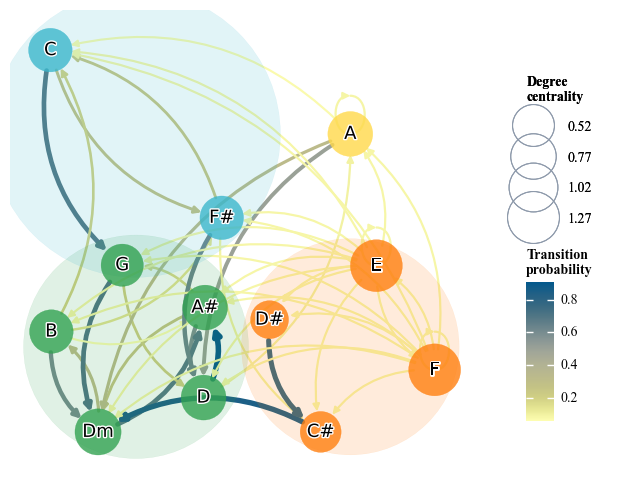

In [9]:

# # 创建颜色映射对象
# cmap = Davos_4.mpl_colormap
# # 截取中间50%的颜色
# start, end = 0.25, 0.8
# cmap = truncate_colormap(cmap, start, end)
# num_communities = len(communities)
# colors = [cmap(i / num_communities) for i in range(num_communities)]

colors=GreenOrange_6.colors
colors = np.array(GreenOrange_6.colors) / 255.0
# 根据社区ID为节点分配颜色
node_colors = [colors[community_dict[node]] for node in G.nodes()]

# 节点的度中心性
centrality = nx.degree_centrality(G)
# 标准化节点大小
scaler = MinMaxScaler(feature_range=(750, 1400))  # 节点大小在100到1000之间
node_sizes = scaler.fit_transform(np.array(list(centrality.values())).reshape(-1, 1)).flatten()

# 标准化边宽度
weights = [G[u][v]['weight'] for u, v in G.edges()]
scaled_weights = MinMaxScaler(feature_range=(1.5, 4)).fit_transform(np.array(weights).reshape(-1, 1)).flatten()  # 边宽度在0.5到5之间
# 创建一个颜色映射，从浅蓝渐变到深蓝
cmap = reverse_colormap(Nuuk_13.mpl_colormap)
norm = mcolors.Normalize(vmin=min(weights), vmax=max(weights))
edge_colors = [cmap(norm(weight)) for weight in weights]


# 社区布局和偏移
num_communities = len(communities)
grid_size = math.ceil(math.sqrt(num_communities))  # 计算网格行列数
offset_increment = 2.5  # 调整每个社区的偏移增量以更好地分隔社区
offsets = [[i % grid_size * offset_increment, i // grid_size * offset_increment] for i in range(num_communities)]

# 应用spring_layout
pos = {}
community_layers = [list(community) for community in communities]
for offset, community in zip(offsets, community_layers):
    # 为每个社区应用spring布局，增加k值以增加社区内节点间距
    k_value = len(community) * 1  # k值可能需要根据社区大小进行调整
    community_pos = nx.spring_layout(G.subgraph(community), k=k_value, seed=42, scale=1)
    community_pos = {node: (location[0] + offset[0], location[1] + offset[1]) for node, location in community_pos.items()}
    pos.update(community_pos)


# 创建图形和轴对象
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_axis_off()  # 关闭坐标轴
nodes =nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, alpha=0.8, ax=ax)
labels =nx.draw_networkx_labels(G, pos, font_size=13, ax=ax)
edges =nx.draw_networkx_edges(G, pos, width=scaled_weights, arrowstyle='-|>', arrowsize=10, edge_color=edge_colors, connectionstyle='arc3,rad=0.3', ax=ax,
    min_source_margin=15,  # 调整源节点边缘的偏移量
    min_target_margin=15)

# 为每个标签添加白色描边
for label in labels.values():
    label.set_path_effects([
        path_effects.Stroke(linewidth=2, foreground='white'),  # 白色描边
        path_effects.Normal()
    ])


# 设置透明背景
fig.patch.set_alpha(0)
quartiles = np.round(np.linspace(np.min(list(centrality.values())), np.max(list(centrality.values())), num=5)[1:], 2)
# 创建大小图例
a=size_legend(sizes=np.arange(750, 1400, 1), handle="circle", ax=ax,labels=quartiles,colors='#8E9AAB',title='Degree\ncentrality',fill=False, labelspacing=1.2,  # 增加标签间距
    handletextpad=2)
# 调整图例标题样式和位置
title = a.get_title()
title.set_position((0.5, 9))  # 调整标题的位置相对于图例框
# 创建颜色映射
truncated_cmap = reverse_colormap(Nuuk_13.mpl_colormap)
# 创建颜色图例
norm = plt.Normalize(vmin=min(weights), vmax=max(weights))
mappable = plt.cm.ScalarMappable(norm=norm, cmap=truncated_cmap)
b=colorart(mappable, ax=ax, loc="out right center",title='Transition\nprobability')
vstack([a, b], spacing=17, title="", loc="out right center", frameon=False, ax=ax)


# 对每个社区绘制一个基于社区颜色的圆形（在所有图层下面）
for idx, community in enumerate(communities):
    # 获取社区内节点的位置
    community_positions = np.array([pos[node] for node in community])
    center = community_positions.mean(axis=0)
    radius = np.max(np.linalg.norm(community_positions - center, axis=1))
    # 增加一些边距
    radius *= 1.2
    # 使用之前为每个社区定义的颜色
    circle = plt.Circle(center, radius, color=colors[idx], alpha=0.15)  # 使用定义好的颜色并设置透明度
    ax.add_artist(circle)

plt.savefig('test.svg', bbox_inches='tight', pad_inches=0.1)
plt.show()

In [10]:
# 遍历每个转移矩阵
for key, transition_df in tqdm(transition_matrices.items(), desc="Generating graphs"):
    transition_df = transition_matrices[key]
    # 获取转移概率矩阵和状态列表
    transition_probabilities = transition_df.copy()
    transition_probabilities = convert_transition_matrix(transition_probabilities)
    # 归一化转移概率矩阵
    transition_probabilities = transition_probabilities.div(transition_probabilities.sum(axis=1), axis=0)
    # 清理矩阵：将小于 0.05 的值设置为 0
    transition_probabilities[transition_probabilities < 0.05] = 0
    # 获取和弦名称列表
    chord_names = transition_probabilities.columns.tolist()
    # 转换为 NumPy 数组
    markov_matrix = transition_probabilities.round(3).values
    import math
    
    # 创建有向图
    G = nx.DiGraph()
    for i, from_chord in enumerate(chord_names):
        for j, to_chord in enumerate(chord_names):
            weight = markov_matrix[i, j]
            if weight > 0:
                G.add_edge(from_chord, to_chord, weight=weight)
    
    # 社区检测
    centrality = nx.algorithms.degree_centrality(G)
    communities = list(nx.algorithms.community.greedy_modularity_communities(G))
    community_dict = {node: cid for cid, community in enumerate(communities) for node in community}
    
    # # 创建颜色映射对象
    # cmap = Davos_4.mpl_colormap
    # # 截取中间50%的颜色
    # start, end = 0.25, 0.8
    # cmap = truncate_colormap(cmap, start, end)
    # num_communities = len(communities)
    # colors = [cmap(i / num_communities) for i in range(num_communities)]
    
    colors = GreenOrange_6.colors
    colors = np.array(GreenOrange_6.colors) / 255.0
    # 根据社区ID为节点分配颜色
    node_colors = [colors[community_dict[node]] for node in G.nodes()]
    
    # 节点的度中心性
    centrality = nx.degree_centrality(G)
    # 标准化节点大小
    scaler = MinMaxScaler(feature_range=(750, 1400))  # 节点大小在100到1000之间
    node_sizes = scaler.fit_transform(np.array(list(centrality.values())).reshape(-1, 1)).flatten()
    
    # 标准化边宽度
    weights = [G[u][v]['weight'] for u, v in G.edges()]
    scaled_weights = MinMaxScaler(feature_range=(1.5, 4)).fit_transform(
        np.array(weights).reshape(-1, 1)).flatten()  # 边宽度在0.5到5之间
    # 创建一个颜色映射，从浅蓝渐变到深蓝
    cmap = reverse_colormap(Nuuk_13.mpl_colormap)
    norm = mcolors.Normalize(vmin=min(weights), vmax=max(weights))
    edge_colors = [cmap(norm(weight)) for weight in weights]
    
    # 社区布局和偏移
    num_communities = len(communities)
    grid_size = math.ceil(math.sqrt(num_communities))  # 计算网格行列数
    offset_increment = 2.5  # 调整每个社区的偏移增量以更好地分隔社区
    offsets = [[i % grid_size * offset_increment, i // grid_size * offset_increment] for i in range(num_communities)]
    
    # 应用spring_layout
    pos = {}
    community_layers = [list(community) for community in communities]
    for offset, community in zip(offsets, community_layers):
        # 为每个社区应用spring布局，增加k值以增加社区内节点间距
        k_value = len(community) * 1  # k值可能需要根据社区大小进行调整
        community_pos = nx.spring_layout(G.subgraph(community), k=k_value, seed=42, scale=1)
        community_pos = {node: (location[0] + offset[0], location[1] + offset[1]) for node, location in
                         community_pos.items()}
        pos.update(community_pos)
    
    # 创建图形和轴对象
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.set_axis_off()  # 关闭坐标轴
    nodes = nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, alpha=0.8, ax=ax)
    labels = nx.draw_networkx_labels(G, pos, font_size=13, ax=ax)
    edges = nx.draw_networkx_edges(G, pos, width=scaled_weights, arrowstyle='-|>', arrowsize=10, edge_color=edge_colors,
                                   connectionstyle='arc3,rad=0.3', ax=ax,
    min_source_margin=15,  # 调整源节点边缘的偏移量
    min_target_margin=15)
    
    # 为每个标签添加白色描边
    for label in labels.values():
        label.set_path_effects([
            path_effects.Stroke(linewidth=2, foreground='white'),  # 白色描边
            path_effects.Normal()
        ])
    
    # 设置透明背景
    fig.patch.set_alpha(0)
    quartiles = np.round(np.linspace(np.min(list(centrality.values())), np.max(list(centrality.values())), num=5)[1:], 2)
    # 创建大小图例
    a = size_legend(sizes=np.arange(750, 1400, 1), handle="circle", ax=ax, labels=quartiles, colors='#8E9AAB',
                    title='Degree\ncentrality', fill=False, labelspacing=1.2,  # 增加标签间距
                    handletextpad=2)
    # 调整图例标题样式和位置
    title = a.get_title()
    title.set_position((0.5, 9))  # 调整标题的位置相对于图例框
    # 创建颜色映射
    truncated_cmap = reverse_colormap(Nuuk_13.mpl_colormap)
    # 创建颜色图例
    norm = plt.Normalize(vmin=min(weights), vmax=max(weights))
    mappable = plt.cm.ScalarMappable(norm=norm, cmap=truncated_cmap)
    b = colorart(mappable, ax=ax, loc="out right center", title='Transition\nprobability')
    vstack([a, b], spacing=17, title="", loc="out right center", frameon=False, ax=ax)
    
    # 对每个社区绘制一个基于社区颜色的圆形（在所有图层下面）
    for idx, community in enumerate(communities):
        # 获取社区内节点的位置
        community_positions = np.array([pos[node] for node in community])
        center = community_positions.mean(axis=0)
        radius = np.max(np.linalg.norm(community_positions - center, axis=1))
        # 增加一些边距
        radius *= 1.2
        # 使用之前为每个社区定义的颜色
        circle = plt.Circle(center, radius, color=colors[idx], alpha=0.15)  # 使用定义好的颜色并设置透明度
        ax.add_artist(circle)
        
    network_svg_path = os.path.join(output_folder, f"{key}_network.svg")
    plt.savefig(network_svg_path, bbox_inches='tight', pad_inches=0.1)
    # 关闭当前绘图，防止图像在 Jupyter Notebook 中展示
    plt.close()

    

Generating graphs: 100%|██████████| 93/93 [01:22<00:00,  1.13it/s]


In [11]:
import random

for key, transition_df in tqdm(transition_matrices.items(), desc="Generating graphs"):
    transition_df = transition_matrices[key]
    # 获取转移概率矩阵和状态列表
    transition_probabilities = transition_df.copy()
    transition_probabilities = convert_transition_matrix(transition_probabilities)
    # 归一化转移概率矩阵
    transition_probabilities = transition_probabilities.div(transition_probabilities.sum(axis=1), axis=0)
    # 清理矩阵：将小于 0.05 的值设置为 0
    transition_probabilities[transition_probabilities < 0.05] = 0
    # 获取和弦名称列表
    chord_names = transition_probabilities.columns.tolist()
    # 转换为 NumPy 数组
    markov_matrix = transition_probabilities.round(3).values

    # 遍历每个和弦节点
    for keys in chord_names:
        # 初始化当前和弦为起始和弦
        current_chord = keys
        generated_sequence = [current_chord]
    
        # 生成和弦序列
        sequence_length = 50  # 序列的长度为20
        for _ in range(sequence_length - 1):
            current_index = chord_names.index(current_chord)
            # 根据转移矩阵生成下一个和弦
            next_chord = random.choices(chord_names, weights=markov_matrix[current_index])[0]
            generated_sequence.append(next_chord)
            current_chord = next_chord
    
          # 将生成的和弦序列追加到 txt 文件（使用 'a' 模式）
        filename = os.path.join(output_folder, f"{key}.txt")
        with open(filename, "a") as file:  # 使用 'a' 模式来追加内容
            file.write(" -> ".join(generated_sequence))
            file.write("\n")  # 添加换行符
            file.write("\n")  # 添加换行符
            file.write("\n")  # 添加换行符
            file.write("\n")  # 添加换行符

Generating graphs: 100%|██████████| 93/93 [00:02<00:00, 31.80it/s]
